In [1]:
pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.80.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.8 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.9 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using c

In [2]:
import os
import random
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
import seaborn as sns

I0000 00:00:1779901239.234730    1010 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779901239.288686    1010 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779901241.066851    1010 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Create a small dataset

In [3]:
#Read the dataset
paths = {
    "shadows_positive": "OneDrive_1_23-3-2026 (1)/Images for Classification with Noise/Shadow_Postive",
    "shadows_negative": "OneDrive_1_23-3-2026 (1)/Images for Classification with Noise/Shadow_Negative",
    "rays_shallow_positive": "OneDrive_1_23-3-2026 (1)/rayTracingShalowWater_10_15 1/rayTracingShalowWater_positive_10_15",
    "rays_shallow_negative": "OneDrive_1_23-3-2026 (1)/rayTracingShalowWater_10_15 1/rayTracingShalowWater_negative_10_15",
    "rays_deep_positive": "OneDrive_1_23-3-2026 (1)/imagesGaussianNoise_08_31 (1)/rayTracingDeepWater_positiveGaussNoise_08_31",
    "rays_deep_negative": "OneDrive_1_23-3-2026 (1)/imagesGaussianNoise_08_31 (1)/rayTracingDeepWater_negativeGaussNoise_08_31"
}

In [4]:
#GEt the images from the dataset
def list_images(folder):
    img = {".jpg", ".jpeg", ".png"}
    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if os.path.splitext(f)[1].lower() in img
    ]

In [5]:
#Sample n images from a folder
def sample_images(folder):
    imgs = list_images(folder)
    return imgs

In [6]:
#Read paths
shadow_imgs_positive = sample_images(paths["shadows_positive"])
shadow_imgs_negative = sample_images(paths["shadows_negative"])
shallow_imgs_positive = sample_images(paths["rays_shallow_positive"])
shallow_imgs_negative = sample_images(paths["rays_shallow_negative"])
deep_imgs_positive = sample_images(paths["rays_deep_positive"])
deep_imgs_negative = sample_images(paths["rays_deep_negative"])
#BUild dataframe
rows = (
    [(p, 1, "shadow_positive") for p in shadow_imgs_positive] +
    [(p, 0, "shadow_negative") for p in shadow_imgs_negative] +
    [(p, 1, "rays_shallow_positive") for p in shallow_imgs_positive] +
    [(p, 0, "rays_shallow_negative") for p in shallow_imgs_negative] +
    [(p, 1, "rays_deep_positive") for p in deep_imgs_positive] +
    [(p, 0, "rays_deep_negative") for p in deep_imgs_negative]
)

df = pd.DataFrame(rows, columns=["path", "label", "source"])
print(f"\nTotal: {len(df)} images \nCracks: {df.label.sum()} \nNon-cracks: {(df.label==0).sum()}")



Total: 18070 images 
Cracks: 9035 
Non-cracks: 9035


In [7]:
#Show some images
classes = ["shadow_positive", "shadow_negative", "rays_shallow_positive", "rays_shallow_negative", "rays_deep_positive", "rays_deep_negative"]

## Preprocess the data

### Simple preprocessing function

In [8]:
import cv2
import numpy as np

def preprocess_image_clahe(path):
    #Load image as grayscale
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)    
    #Resize
    img_res = cv2.resize(img, (128, 128), interpolation=cv2.INTER_LINEAR)
    #clipLimit to manage contrast threshold, tileGridSize divides the image into local blocks
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_res)
    #normalise
    img_norm = img_clahe.astype(np.float32) / 255.0    
    
    return img_norm

In [9]:
def preprocess_image_simple(path):
    #Load images
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    #Resize
    img_res = cv2.resize(img, (128,128), interpolation=cv2.INTER_LINEAR)        
    #Normalise
    img_norm = img_res.astype(np.float32) / 255.0    
    return img_norm

processed_imgs_simple = []
for p in df["path"]:
    processed_imgs_simple.append(preprocess_image_simple(p))

In [ ]:
df["path"][0]
df["path"][10000]
df["path"][17000]

In [37]:
df["path"][18000]

'OneDrive_1_23-3-2026 (1)/imagesGaussianNoise_08_31 (1)/rayTracingDeepWater_negativeGaussNoise_08_31/rayTrTams2_(252)_100.jpg'

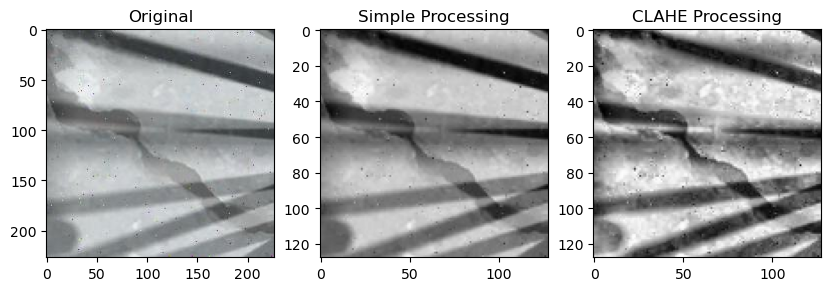

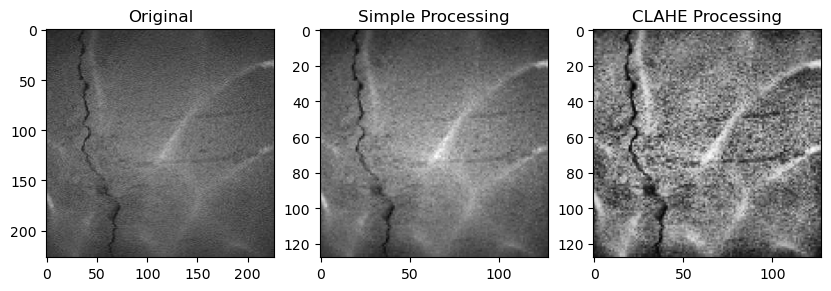

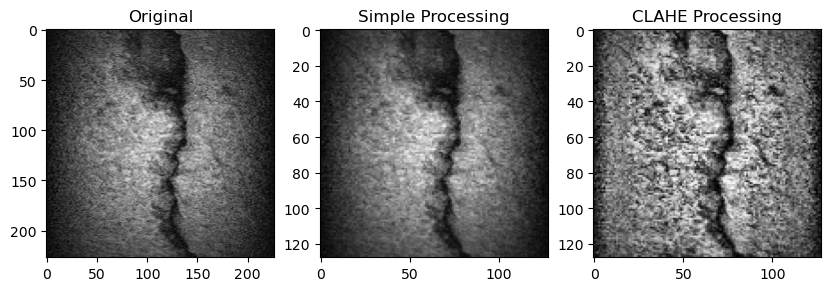

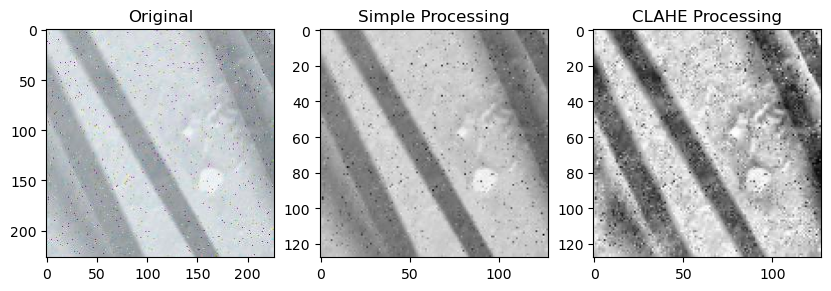

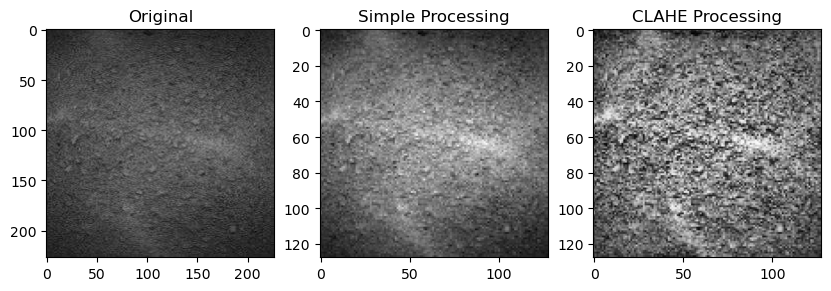

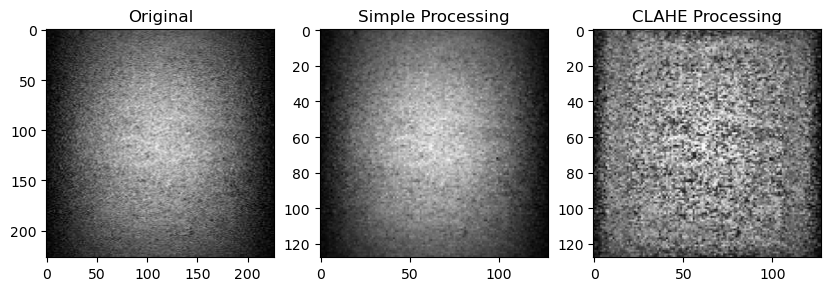

In [38]:
#Visualisation before and after
#sample_path = df["path"].iloc[97:100]
sample_path = [df["path"][0],df["path"][11000],df["path"][16000],
               df["path"][5000], df["path"][12000],df["path"][18000]]
original = []
clahe = [] 
simple = []
for p in sample_path:
    original.append(cv2.imread(p))
    clahe.append(preprocess_image_clahe(p))
    simple.append(preprocess_image_simple(p))

for i in range(len(sample_path)):
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))
    axes[0].imshow(original[i], cmap='gray')
    axes[0].set_title("Original")
    axes[1].imshow(simple[i], cmap='gray')
    axes[1].set_title("Simple Processing")
    axes[2].imshow(clahe[i], cmap='gray')
    axes[2].set_title("CLAHE Processing")
    plt.show()

In [39]:
def plot_history(history):
    #PLot the training performance
    plt.plot(history.history['loss'],label="train")
    plt.plot(history.history['val_loss'],label="validation")
    plt.title('Model Loss')
    plt.yscale('log')
    plt.ylabel('Cross Entropy')
    plt.xlabel('Iteration')
    plt.grid()
    plt.legend()
    plt.show()

    plt.plot(history.history['sparse_categorical_accuracy'],label="train")
    plt.plot(history.history['val_sparse_categorical_accuracy'],label="validation")
    plt.title('Model Accuracy')
    plt.ylabel('Acc')
    plt.xlabel('Iteration')
    plt.grid()
    plt.legend()
    plt.show()

## Train model for each situation (ray deep water, ray shalow water, shadow)

In [40]:
df.to_csv("dataframe.csv", index=False)

In [41]:
#Get df by source
df['source_group'] = df['source'].str.extract(r'^(shadow|rays_shallow|rays_deep)', expand=False)
grouped_dfs = {group: group_df for group, group_df in df.groupby('source_group')}
shadow_df = grouped_dfs['shadow']
rays_shallow_df = grouped_dfs['rays_shallow']
rays_deep_df = grouped_dfs['rays_deep']

In [42]:
shadow_df['processed_images'] = ([preprocess_image_clahe(p) for p in shadow_df["path"]])
rays_shallow_df['processed_images'] = ([preprocess_image_clahe(p) for p in rays_shallow_df["path"]])
rays_deep_df['processed_images'] = ([preprocess_image_clahe(p) for p in rays_deep_df["path"]])

In [43]:
#Split dataframes in train and test sets with shuffle and stratify
shadow_train, shadow_test = train_test_split(shadow_df, test_size=0.2, stratify=shadow_df['label'], random_state=2000)
rays_shallow_train, rays_shallow_test = train_test_split(rays_shallow_df, test_size=0.2, stratify=rays_shallow_df['label'], random_state=2000)
rays_deep_train, rays_deep_test = train_test_split(rays_deep_df, test_size=0.2, stratify=rays_deep_df['label'], random_state=2000)

In [45]:
X_shadow_train = np.stack(shadow_train['processed_images']).astype('float32')
y_shadow_train = np.array(shadow_train['label']).astype('int32')

X_shadow_test = np.stack(shadow_test['processed_images']).astype('float32')
y_shadow_test = np.array(shadow_test['label']).astype('int32')

X_rays_shallow_train = np.stack(rays_shallow_train['processed_images']).astype('float32')
y_rays_shallow_train = np.array(rays_shallow_train['label']).astype('int32')

X_rays_shallow_test = np.stack(rays_shallow_test['processed_images']).astype('float32')
y_rays_shallow_test = np.array(rays_shallow_test['label']).astype('int32')

X_rays_deep_train = np.stack(rays_deep_train['processed_images']).astype('float32')
y_rays_deep_train = np.array(rays_deep_train['label']).astype('int32')

X_rays_deep_test = np.stack(rays_deep_test['processed_images']).astype('float32')
y_rays_deep_test = np.array(rays_deep_test['label']).astype('int32')

In [46]:
cnn_simple = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)), 
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(2, activation='softmax')
])

In [47]:
cnn_simple.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,434 (1009.51 KB)

 Trainable params: 257,730 (1006.76 KB)

 Non-trainable params: 704 (2.75 KB)

In [48]:
cnn_simple.build(input_shape=[None,128,128,1])
cnn_simple.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
)

In [50]:
print(X_rays_deep_train.shape)
print(X_shadow_train.shape)
print(X_rays_shallow_train.shape)

(2824, 128, 128)
(7520, 128, 128)
(4112, 128, 128)


In [51]:
print(X_rays_deep_test.shape)
print(X_shadow_test.shape)
print(X_rays_shallow_test.shape)

(706, 128, 128)
(1880, 128, 128)
(1028, 128, 128)


In [52]:
#Ctreate the new training dataset
X_train = np.concatenate([X_shadow_train, X_rays_shallow_train, X_rays_deep_train], axis=0)
y_train = np.concatenate([y_shadow_train, y_rays_shallow_train, y_rays_deep_train], axis=0)

In [53]:
X_train.shape[0]

14456

In [54]:
#Labels for source to know where are the errrors
source_shadow = np.full(y_shadow_test.shape[0], 'shadow')
source_rays_shallow = np.full(y_rays_shallow_test.shape[0], 'rays_shallow')
source_rays_deep = np.full(y_rays_deep_test.shape[0], 'rays_deep')

In [55]:
#Create the new dataset joining the new
X_test = np.concatenate([X_shadow_test, X_rays_shallow_test, X_rays_deep_test], axis=0)
y_test = np.concatenate([y_shadow_test, y_rays_shallow_test, y_rays_deep_test], axis=0)

source_test = np.concatenate([source_shadow, source_rays_shallow, source_rays_deep], axis=0)

In [56]:
#Shuffle the new dataset
from sklearn.utils import shuffle
X_test, y_test, source_test = shuffle(X_test, y_test, source_test, random_state=2000)

Epoch 1/100
452/452 - 205s - 453ms/step - loss: 0.4793 - sparse_categorical_accuracy: 0.7690 - val_loss: 1.9302 - val_sparse_categorical_accuracy: 0.5008
Epoch 2/100
452/452 - 69s - 153ms/step - loss: 0.3343 - sparse_categorical_accuracy: 0.8551 - val_loss: 0.2658 - val_sparse_categorical_accuracy: 0.8863
Epoch 3/100
452/452 - 70s - 154ms/step - loss: 0.2728 - sparse_categorical_accuracy: 0.8876 - val_loss: 0.2295 - val_sparse_categorical_accuracy: 0.9145
Epoch 4/100
452/452 - 69s - 152ms/step - loss: 0.2361 - sparse_categorical_accuracy: 0.9030 - val_loss: 0.2370 - val_sparse_categorical_accuracy: 0.8987
Epoch 5/100
452/452 - 61s - 135ms/step - loss: 0.2122 - sparse_categorical_accuracy: 0.9168 - val_loss: 0.1972 - val_sparse_categorical_accuracy: 0.9211
Epoch 6/100
452/452 - 60s - 133ms/step - loss: 0.1834 - sparse_categorical_accuracy: 0.9287 - val_loss: 0.2176 - val_sparse_categorical_accuracy: 0.9095
Epoch 7/100
452/452 - 77s - 170ms/step - loss: 0.1636 - sparse_categorical_accura

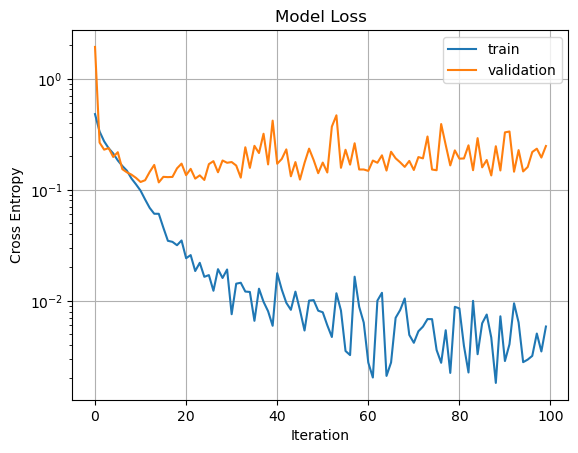

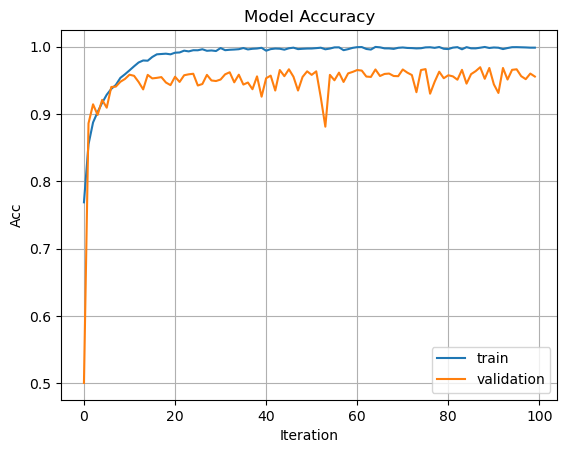

In [57]:
#Train loop for all data
history = cnn_simple.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=100,
    verbose=2,
    validation_data=(X_test, y_test),
)
plot_history(history)

In [63]:
#Get predictions
y_pred = np.argmax(cnn_simple.predict(X_test), axis=1)
df_res = pd.DataFrame({'Truth': y_test, 'Prediction': y_pred, 'Source': source_test})

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


In [64]:
#Get predictions
y_prob = cnn_simple.predict(X_test)
y_prob_positive = y_prob[:,1]
y_pred = np.argmax(y_prob, axis=1)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [65]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_positive), 4))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

Accuracy : 0.9557
Precision: 0.9698
Recall   : 0.9408
F1-score : 0.9551
ROC AUC  : 0.9898

Classification report:

              precision    recall  f1-score   support

           0     0.9425    0.9707    0.9564      1807
           1     0.9698    0.9408    0.9551      1807

    accuracy                         0.9557      3614
   macro avg     0.9561    0.9557    0.9557      3614
weighted avg     0.9561    0.9557    0.9557      3614



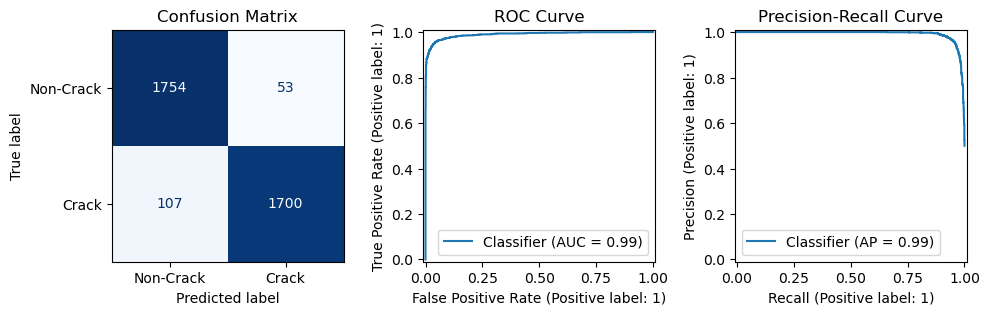

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Non-Crack", "Crack"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob_positive, ax=axes[1])
axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob_positive, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [67]:
#Get the confusion matrix etc per source
for source in df_res['Source'].unique():
    subset = df_res[df_res['Source'] == source]
    print(f"Source: {source}")
    print(classification_report(subset['Truth'], subset['Prediction']))

Source: rays_deep
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       353
           1       1.00      0.95      0.97       353

    accuracy                           0.97       706
   macro avg       0.98      0.97      0.97       706
weighted avg       0.98      0.97      0.97       706

Source: rays_shallow
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       514
           1       1.00      0.93      0.96       514

    accuracy                           0.96      1028
   macro avg       0.97      0.96      0.96      1028
weighted avg       0.97      0.96      0.96      1028

Source: shadow
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       940
           1       0.94      0.94      0.94       940

    accuracy                           0.94      1880
   macro avg       0.94      0.94      0.94      1880
weighted avg       0

In [68]:
import sklearn

In [69]:
for source in df_res['Source'].unique():
    subset = df_res[df_res['Source'] == source]
    print(f"Source: {source}")
    print(sklearn.metrics.confusion_matrix(subset['Truth'], subset['Prediction']))

Source: rays_deep
[[353   0]
 [ 18 335]]
Source: rays_shallow
[[514   0]
 [ 37 477]]
Source: shadow
[[887  53]
 [ 52 888]]


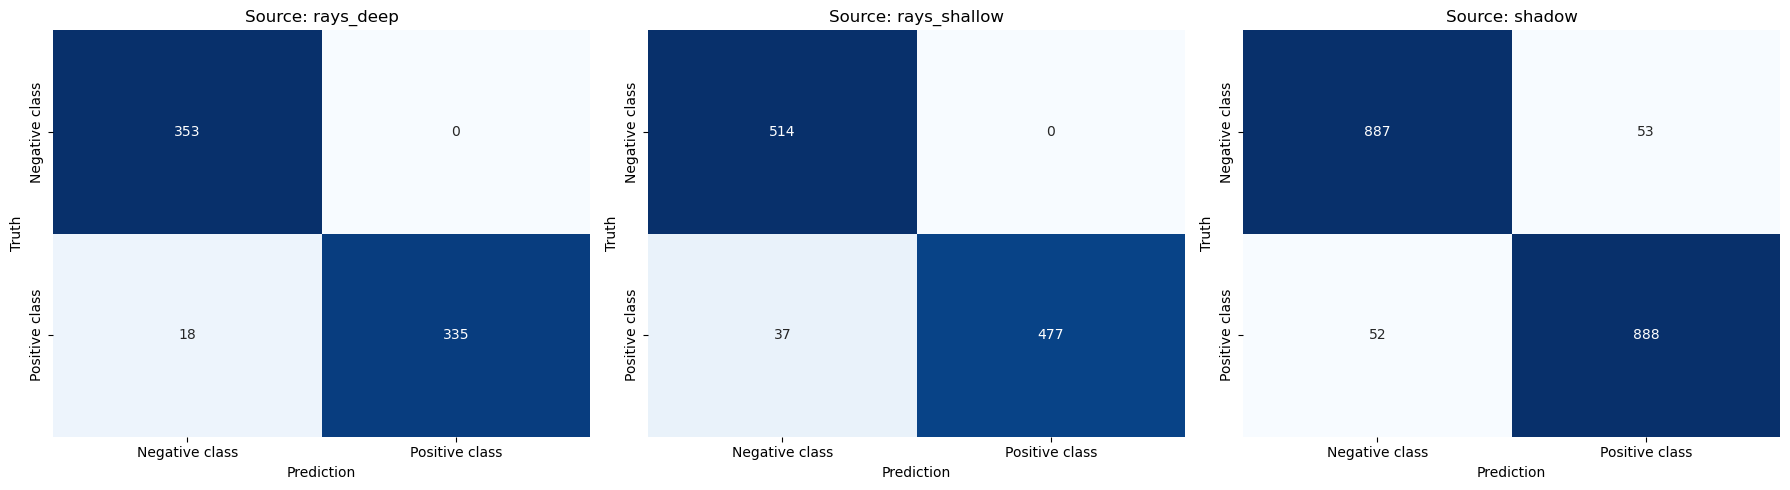

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, source in enumerate(df_res['Source'].unique()):
    subset = df_res[df_res['Source'] == source]
    cm = sklearn.metrics.confusion_matrix(subset['Truth'], subset['Prediction'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Source: {source}')
    axes[i].set_xlabel('Prediction')
    axes[i].set_ylabel('Truth')
    axes[i].set_xticklabels(['Negative class', 'Positive class'])
    axes[i].set_yticklabels(['Negative class', 'Positive class'])

plt.tight_layout()
plt.show()